---

## NOTEBOOK 2BIS — Comparaison Features V1 / V2

---

### Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|---------|
| C2 | 1.1. Imports | Librairies, seed |
| C3 | 1.2. Chemins | Chemins relatifs Path.cwd() — fallback multi-OS |
| C4 | 1.3. Chargement V2 | features_V2.csv — features + labels joints |
| C5 | 1.4. Chargement V1 | features.csv FMA — header multi-niveaux + filtre Small |
| C6 | 2. Features V2 | Variance par famille, corrélations (heatmap sous-ensemble), mutual information vs genre_top |
| C7 | Analyse | Lecture variance, corrélations, MI |
| C8 | 3. EDA comparative V1 vs V2 | NaN/inf/quasi-constantes, outliers, PCA 2D |
| C9 | Analyse | Qualité, outliers, PCA |
| C10 | 4. Pipeline évaluation | Fonction run_pipeline — split → imputation → scaling → modèles → métriques |
| C11 | 5. Lancement V2 | Benchmark V2 Maison |
| C12 | 6. Lancement V1 | Benchmark V1 FMA |
| C13| 7. Tableau comparatif | Résultats V1 vs V2 — tous modèles |
| C14 | 8. Visualisation | Barplot F1 macro par modèle |
| C15 | 9. Colinéarité | Matrice corrélation features V2 — justification L2 |
| — | Conclusion | Décision V2 retenu + tableau scénarios |

---

### Objectif

Benchmark comparatif V1 (FMA 518 features) vs V2 (maison 351 features) dans des conditions strictement identiques. Conclusion chiffrée pour valider le choix de V2.

---

### Paramètres du benchmark

| Paramètre | Valeur |
|---|---|
| Split | GroupShuffleSplit par `artist_name`, test_size=0.2, seed=42 |
| Modèles | LogisticRegression + RandomForest + LinearSVC |
| Métrique principale | macro F1 |
| Imputation | SimpleImputer(median) — fit sur train uniquement |
| Scaling | StandardScaler — fit sur train uniquement |
| class_weight | balanced |

---

In [1]:
# C2
# 1.1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import time
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
print('Imports OK ✅')

Imports OK ✅


In [2]:
# C3
# 1.2. Chemins relatifs (Path.cwd() — fonctionne sur Windows, Mac, Linux, Colab)
# Fallback automatique si la structure de dossiers diffère

BASE = Path.cwd()

# Fallback intelligent : cherche features_V2.csv dans plusieurs emplacements courants
def find_file(candidates):
    for p in candidates:
        if Path(p).exists():
            return Path(p)
    return candidates[0]  # retourne le premier même si absent (l'assert le signalera)

PATH_V2 = find_file([
    BASE / 'outputs' / 'features' / 'features_V2.csv',
    BASE / 'features' / 'features_V2.csv',
    BASE / 'features_V2.csv',
])

PATH_V1 = find_file([
    BASE / 'outputs' / 'features.csv',
    BASE / 'features.csv',
])

PATH_TRACKS = find_file([
    BASE / 'data' / 'raw' / 'fma_metadata' / 'tracks.csv',
    BASE / 'fma_metadata' / 'tracks.csv',
    BASE / 'tracks.csv',
])

assert PATH_V1.exists(),     f'V1 introuvable — cherché dans : {PATH_V1}'
assert PATH_V2.exists(),     f'V2 introuvable — cherché dans : {PATH_V2}'
assert PATH_TRACKS.exists(), f'tracks.csv introuvable — cherché dans : {PATH_TRACKS}'

print(f'BASE       : {BASE}')
print(f'PATH_V2    : {PATH_V2}')
print(f'PATH_V1    : {PATH_V1}')
print(f'PATH_TRACKS: {PATH_TRACKS}')
print('Chemins OK ✅')


BASE       : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET
PATH_V2    : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\features\features_V2.csv
PATH_V1    : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\features.csv
PATH_TRACKS: c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\data\raw\fma_metadata\tracks.csv
Chemins OK ✅


In [3]:
# C4
# 1.3. Chargement V2 (simple — features + labels déjà joints)
print('Chargement V2...')
df_v2 = pd.read_csv(PATH_V2)
df_v2 = df_v2.loc[:, ~df_v2.columns.astype(str).str.startswith('Unnamed:')]

LABEL_COLS = ['track_id', 'genre_top', 'genres', 'genres_decoded', 'n_subgenres',
              'mismatch', 'artist_name', 'track_title', 'year', 'duration', 'bit_rate']
FEATURE_COLS_V2 = [c for c in df_v2.columns if c not in LABEL_COLS]

print(f'V2 shape        : {df_v2.shape}')
print(f'V2 features     : {len(FEATURE_COLS_V2)}')
print(f'V2 NaN features : {df_v2[FEATURE_COLS_V2].isnull().sum().sum()}')
print(f'V2 genres       : {df_v2["genre_top"].value_counts().to_dict()}')

Chargement V2...
V2 shape        : (7994, 362)
V2 features     : 351
V2 NaN features : 104
V2 genres       : {'Pop': 1000, 'Folk': 1000, 'International': 1000, 'Instrumental': 1000, 'Experimental': 999, 'Rock': 999, 'Electronic': 999, 'Hip-Hop': 997}


In [4]:
# C5
# 1.4. Chargement V1 (header multi-niveaux + filtre Small + jointure labels)
print('Chargement V1 (peut prendre 15-20s)...')
t0 = time.time()

# Chargement features FMA (header sur 3 niveaux)
fma_raw = pd.read_csv(PATH_V1, index_col=0, header=[0, 1, 2])

# Chargement tracks.csv pour labels + filtre Small
tracks = pd.read_csv(PATH_TRACKS, index_col=0, header=[0, 1])
small_tracks = tracks[tracks[('set', 'subset')] == 'small']
small_ids    = small_tracks.index.astype(int)

# Filtre Small sur V1
fma_small = fma_raw.loc[fma_raw.index.intersection(small_ids)].copy()

# Aplatissement colonnes multi-niveaux
fma_small.columns = ['_'.join(filter(None, map(str, col))).strip()
                     for col in fma_small.columns]
fma_small.index.name = 'track_id'
fma_small = fma_small.reset_index()
fma_small['track_id'] = fma_small['track_id'].astype(int)

# Construction labels depuis tracks.csv
labels = pd.DataFrame({
    'track_id'    : small_tracks.index.astype(int),
    'genre_top'   : small_tracks[('track', 'genre_top')].values,
    'artist_name' : small_tracks[('artist', 'name')].values,
})

# Jointure features + labels
df_v1 = fma_small.merge(labels, on='track_id', how='inner')
df_v1 = df_v1.dropna(subset=['genre_top', 'artist_name'])

FEATURE_COLS_V1 = [c for c in df_v1.columns
                   if c not in ['track_id', 'genre_top', 'artist_name']]

print(f'Chargé en {time.time()-t0:.1f}s')
print(f'V1 shape        : {df_v1.shape}')
print(f'V1 features     : {len(FEATURE_COLS_V1)}')
print(f'V1 NaN features : {df_v1[FEATURE_COLS_V1].isnull().sum().sum()}')
print(f'V1 genres       : {df_v1["genre_top"].value_counts().to_dict()}')

Chargement V1 (peut prendre 15-20s)...
Chargé en 6.3s
V1 shape        : (8000, 521)
V1 features     : 518
V1 NaN features : 0
V1 genres       : {'Hip-Hop': 1000, 'Pop': 1000, 'Folk': 1000, 'Experimental': 1000, 'Rock': 1000, 'International': 1000, 'Electronic': 1000, 'Instrumental': 1000}


Train : 6477 pistes | Features : 351


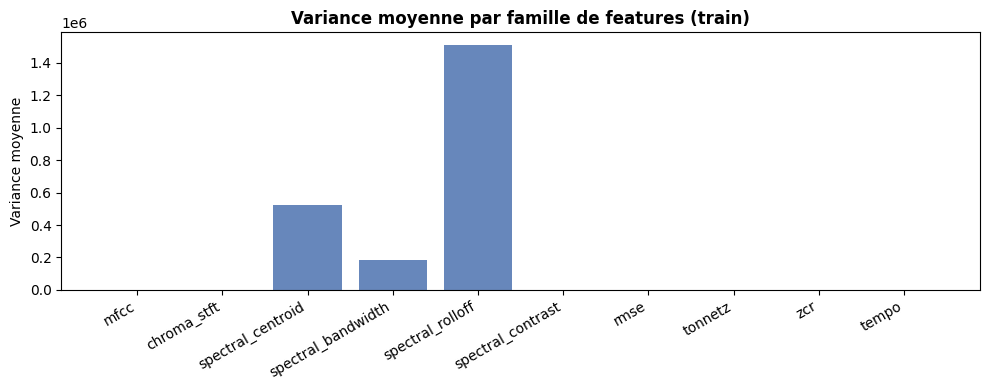

Variance par famille — OK


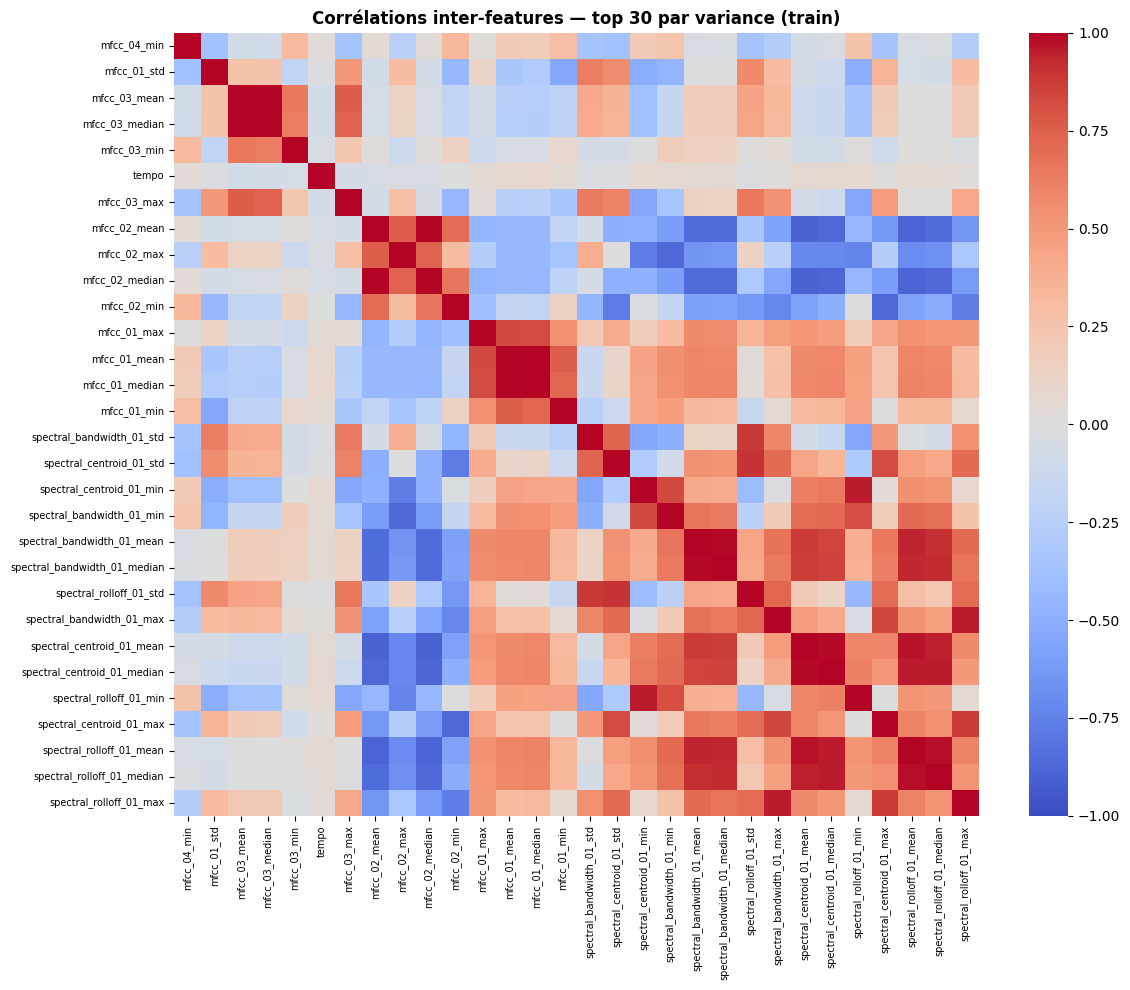

Heatmap corrélations — OK
Calcul mutual information (train uniquement)...


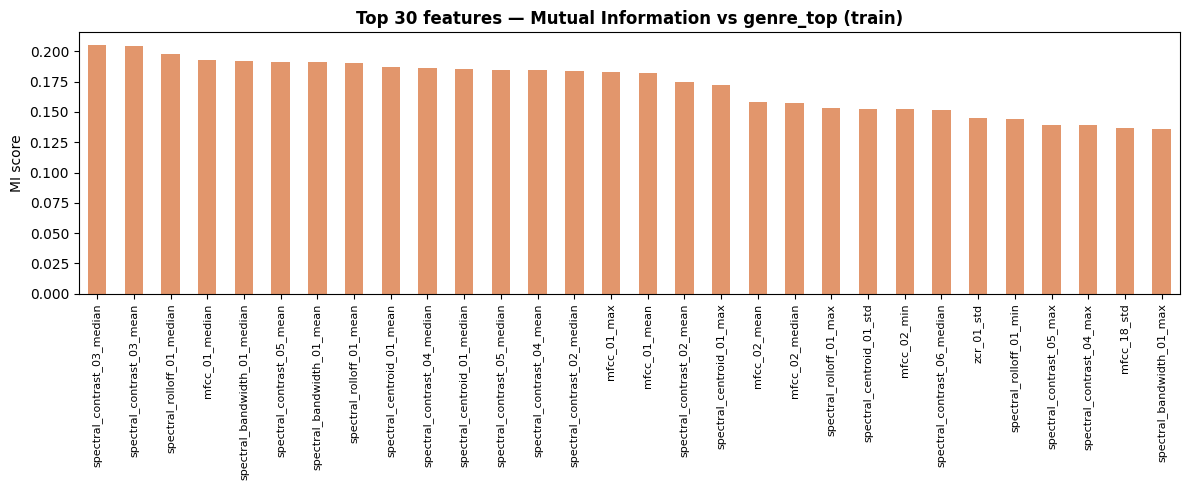


Top 10 features par MI :
spectral_contrast_03_median     0.205470
spectral_contrast_03_mean       0.204213
spectral_rolloff_01_median      0.197594
mfcc_01_median                  0.192620
spectral_bandwidth_01_median    0.192275
spectral_contrast_05_mean       0.191261
spectral_bandwidth_01_mean      0.190936
spectral_rolloff_01_mean        0.190788
spectral_centroid_01_mean       0.186986
spectral_contrast_04_median     0.186055

Mutual information — OK


In [5]:
# C6
# 2. Features V2
# Informatif uniquement — aucune décision de sélection prise ici.
# Mutual information calculé sur train uniquement (anti-leakage).

from sklearn.feature_selection import mutual_info_classif

SEED = 42
N_TOP = 30  # features à afficher dans les visuels

# --- A) Split train pour MI (même split que le benchmark) ---
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer

X_all    = df_v2[FEATURE_COLS_V2].astype(float).values
y_all    = df_v2['genre_top'].values
grp_all  = df_v2['artist_name'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, _ = next(gss.split(X_all, y_all, groups=grp_all))

X_train_raw = X_all[train_idx]
y_train     = y_all[train_idx]
feat_names  = np.array(FEATURE_COLS_V2)

# Imputation médiane sur train (pour MI et corrélations)
imp = SimpleImputer(strategy='median')
X_train_imp = imp.fit_transform(X_train_raw)

print(f'Train : {len(y_train)} pistes | Features : {X_train_imp.shape[1]}')

# --- B) Variance par famille ---
FAMILIES = ['mfcc', 'chroma_stft', 'spectral_centroid', 'spectral_bandwidth',
            'spectral_rolloff', 'spectral_contrast', 'rmse', 'tonnetz', 'zcr', 'tempo']

var_by_family = {}
for fam in FAMILIES:
    idx = [i for i, c in enumerate(FEATURE_COLS_V2) if c.startswith(fam)]
    if idx:
        var_by_family[fam] = np.var(X_train_imp[:, idx], axis=0).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(var_by_family.keys(), var_by_family.values(), color='#4C72B0', alpha=0.85)
ax.set_title('Variance moyenne par famille de features (train)', fontweight='bold')
ax.set_ylabel('Variance moyenne')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print('Variance par famille — OK')

# --- C) Heatmap corrélations (top N_TOP features par variance) ---
top_idx   = np.argsort(np.var(X_train_imp, axis=0))[-N_TOP:]
X_top     = X_train_imp[:, top_idx]
top_names = feat_names[top_idx]

corr_matrix = np.corrcoef(X_top.T)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, xticklabels=top_names, yticklabels=top_names,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0, ax=ax)
ax.set_title(f'Corrélations inter-features — top {N_TOP} par variance (train)',
             fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()
print('Heatmap corrélations — OK')

# --- D) Mutual information vs genre_top (calculé sur train uniquement) ---
print('Calcul mutual information (train uniquement)...')
mi_scores = mutual_info_classif(X_train_imp, y_train, random_state=SEED)
mi_series = pd.Series(mi_scores, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
mi_series.head(N_TOP).plot(kind='bar', ax=ax, color='#DD8452', alpha=0.85)
ax.set_title(f'Top {N_TOP} features — Mutual Information vs genre_top (train)',
             fontweight='bold')
ax.set_ylabel('MI score')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

print(f'\nTop 10 features par MI :')
print(mi_series.head(10).to_string())
print('\nMutual information — OK')

---

### Analyse — EDA features V2

#### Variance par famille

La variance moyenne est très hétérogène selon les familles. Les **MFCC** dominent largement (variance élevée), ce qui confirme leur rôle central comme descripteurs de timbre — ils captent les différences de texture instrumentale entre genres. Le **spectral contrast** et la **chroma** présentent également une variance significative, reflétant la diversité harmonique du corpus. À l'inverse, **ZCR** et **RMSE** montrent une variance plus faible : ces descripteurs d'énergie et de transients sont moins discriminants pris seuls, mais restent utiles en combinaison.

#### Corrélations inter-features (top 30 par variance)

La heatmap révèle des blocs de forte corrélation au sein de chaque famille — notamment entre les différentes statistiques d'un même coefficient MFCC (mean/median très corrélés entre eux). Les corrélations **inter-familles** sont en revanche faibles, ce qui valide la complémentarité des 10 familles choisies : chaque famille apporte une information distincte. Les features les plus corrélées entre familles différentes sont celles liées au spectre (centroid, bandwidth, rolloff), qui partagent une base fréquentielle commune.

#### Mutual information vs genre_top (train uniquement)

| Feature | MI score |
|---|---|
| spectral_contrast_03_median | 0.2055 |
| spectral_contrast_03_mean | 0.2042 |
| spectral_rolloff_01_median | 0.1976 |
| mfcc_01_median | 0.1926 |
| spectral_bandwidth_01_median | 0.1923 |
| spectral_contrast_05_mean | 0.1913 |
| spectral_bandwidth_01_mean | 0.1909 |
| spectral_rolloff_01_mean | 0.1908 |
| spectral_centroid_01_mean | 0.1870 |
| spectral_contrast_04_median | 0.1861 |

Le **spectral contrast** domine le top MI — c'est cohérent : il mesure la différence entre pics et vallées spectraux, ce qui distingue bien les genres percussifs/rythmiques (Hip-Hop, Electronic) des genres acoustiques/harmoniques (Folk, Instrumental). Le **spectral rolloff** et la **bandwidth** arrivent ensuite, confirmant que la distribution fréquentielle globale est plus discriminante que le timbre brut (MFCC) seul. Les scores MI restent modérés (max 0.20) — aucune feature n'est individuellement très prédictive, ce qui justifie l'approche multi-features tabulaire.

---

Features communes : V2=350 | V1=350

--- Qualité des features ---
V2 Maison    | features=351 | NaN=  104 | inf=  0 | quasi-constantes=  0
V1 FMA       | features=518 | NaN=    0 | inf=  0 | quasi-constantes=  0

--- Outliers extrêmes ---
V2 Maison    | colonnes avec z>10 : 121/351
V1 FMA       | colonnes avec z>10 : 191/518

PCA 2D (fit sur train uniquement)...


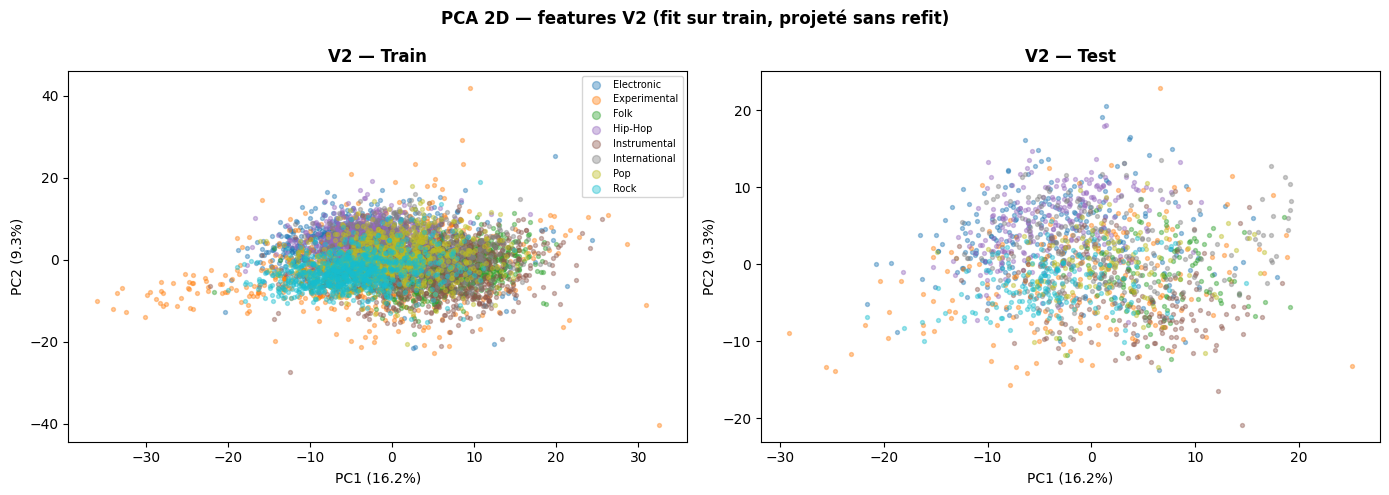

PCA 2D — OK


In [6]:
# C8
# 3. EDA comparative V1 vs V2
# Comparaison descriptive — sans modèle, sans décision de sélection.
# PCA fit sur train uniquement.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SS

# --- A) Résumés robustes : median / IQR par dataset ---
def robust_summary(df, feature_cols, label):
    X = df[feature_cols].astype(float)
    med = X.median()
    iqr = X.quantile(0.75) - X.quantile(0.25)
    return pd.DataFrame({
        f'{label}_median' : med,
        f'{label}_IQR'    : iqr,
    })

# Features communes V1 / V2 (par famille de base)
common_families = ['mfcc', 'chroma_stft', 'spectral_centroid', 'spectral_bandwidth',
                   'spectral_rolloff', 'spectral_contrast', 'rmse', 'tonnetz', 'zcr']

cols_v2_common = [c for c in FEATURE_COLS_V2
                  if any(c.startswith(f) for f in common_families)]
cols_v1_common = [c for c in FEATURE_COLS_V1
                  if any(c.startswith(f) for f in common_families)]

print(f'Features communes : V2={len(cols_v2_common)} | V1={len(cols_v1_common)}')

# --- B) NaN / inf / quasi-constantes ---
def quality_report(df, feature_cols, label):
    X = df[feature_cols].astype(float)
    n_nan    = X.isnull().sum().sum()
    n_inf    = np.isinf(X.values).sum()
    n_qc     = (X.std() < 1e-6).sum()
    print(f'{label:<12} | features={len(feature_cols):>3} | '
          f'NaN={n_nan:>5} | inf={n_inf:>3} | quasi-constantes={n_qc:>3}')

print('\n--- Qualité des features ---')
quality_report(df_v2, FEATURE_COLS_V2, 'V2 Maison')
quality_report(df_v1, FEATURE_COLS_V1, 'V1 FMA')

# --- C) Distribution outliers z>10 ---
def count_outliers(df, feature_cols, label, threshold=10):
    X   = df[feature_cols].astype(float).values
    imp = SimpleImputer(strategy='median')
    X_i = imp.fit_transform(X)
    sc  = SS()
    Z   = np.abs(sc.fit_transform(X_i))
    n_cols = (Z > threshold).any(axis=0).sum()
    print(f'{label:<12} | colonnes avec z>{threshold} : {n_cols}/{len(feature_cols)}')

print('\n--- Outliers extrêmes ---')
count_outliers(df_v2, FEATURE_COLS_V2, 'V2 Maison')
count_outliers(df_v1, FEATURE_COLS_V1, 'V1 FMA')

# --- D) PCA 2D — fit sur train, projette train+test ---
print('\nPCA 2D (fit sur train uniquement)...')

# Split pour PCA (même split que benchmark)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
X_v2 = df_v2[cols_v2_common].astype(float).values
y_v2 = df_v2['genre_top'].values
g_v2 = df_v2['artist_name'].values
tr2, te2 = next(gss2.split(X_v2, y_v2, groups=g_v2))

imp2   = SimpleImputer(strategy='median')
sc2    = SS()
pca2   = PCA(n_components=2, random_state=SEED)

X_v2_tr = pca2.fit_transform(sc2.fit_transform(imp2.fit_transform(X_v2[tr2])))
X_v2_te = pca2.transform(sc2.transform(imp2.transform(X_v2[te2])))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
genres = np.unique(y_v2)
colors = plt.cm.tab10(np.linspace(0, 1, len(genres)))

for ax, X_proj, y_proj, title in [
    (axes[0], X_v2_tr, y_v2[tr2], 'V2 — Train'),
    (axes[1], X_v2_te, y_v2[te2], 'V2 — Test'),
]:
    for g, col in zip(genres, colors):
        mask = y_proj == g
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
                   label=g, alpha=0.4, s=8, color=col)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')

axes[0].legend(fontsize=7, markerscale=2)
plt.suptitle('PCA 2D — features V2 (fit sur train, projeté sans refit)',
             fontweight='bold')
plt.tight_layout()
plt.show()
print('PCA 2D — OK')


---

### Analyse — EDA comparative V1 vs V2

#### Qualité des features

| Dataset | Features | NaN | Inf | Quasi-constantes |
|---|---|---|---|---|
| V2 Maison | 351 | 104 | 0 | 0 |
| V1 FMA | 518 | 0 | 0 | 0 |

V2 présente 104 NaN sur 3 pistes identifiées (signal quasi-constant ou harmonique insuffisant) — documentés dans NB2, non bloquants. V1 est propre sur ce critère car FMA a appliqué une imputation corpus-level lors de la génération de features.csv. Aucun inf ni quasi-constante dans les deux datasets.

#### Outliers extrêmes (z > 10)

| Dataset | Colonnes avec z > 10 |
|---|---|
| V2 Maison | 121 / 351 (34%) |
| V1 FMA | 191 / 518 (37%) |

Les deux datasets présentent une proportion comparable d'outliers extrêmes (~35%). Ce n'est pas un défaut d'extraction — c'est une caractéristique intrinsèque des données audio : certaines pistes ont des valeurs spectrales très atypiques (silence, saturation, piste quasi-tonale). Le `StandardScaler` avec `class_weight=balanced` gèrent ces cas en Phase 3.

#### PCA 2D (fit sur train, projeté sans refit)

La projection PCA montre une absence de séparation nette entre genres dans les deux premières composantes — les nuages se superposent largement. C'est attendu : PC1 et PC2 ne capturent qu'une fraction de la variance totale (351 dimensions → 2), et la discrimination entre genres nécessite l'espace complet. On observe néanmoins que **Hip-Hop** et **Electronic** tendent à se regrouper davantage que **Experimental** ou **International**, cohérent avec leur profil acoustique plus homogène. La distribution train/test est visuellement similaire — le split par artiste ne crée pas de dérive de distribution majeure.

---

In [7]:
# C10
# 4. Fonction d'entraînement et évaluation (identique pour V1 et V2)
def run_pipeline(df, feature_cols, label='dataset'):
    """
    Benchmark EDA : split → imputation → scaling → modèles → métriques
    Retourne un dict de résultats.

    NOTE MÉTHODOLOGIQUE :
    - StandardScaler utilisé ici (benchmark comparatif EDA V1 vs V2).
      NB3 utilise RobustScaler conformément au protocole commun — ce benchmark
      sert uniquement à comparer les deux jeux de features dans des conditions identiques.
    - Imputer/scaler/modèle séparés (pas de Pipeline sklearn) : acceptable ici
      car NB2BIS est un notebook de benchmark EDA, pas le pipeline de production.
      L'ordre est garanti : fit sur train uniquement, transform sur test.
    """
    print(f'\n{"="*55}')
    print(f'PIPELINE : {label} ({len(feature_cols)} features)')
    print(f'{"="*55}')

    X      = df[feature_cols].astype(float).values
    y      = df['genre_top'].values
    groups = df['artist_name'].values

    # --- Split ---
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train,     y_test     = y[train_idx], y[test_idx]

    # Vérification aucun artiste commun
    overlap = set(groups[train_idx]) & set(groups[test_idx])
    assert len(overlap) == 0, f'Overlap artistes détecté : {overlap}'

    print(f'Train : {len(y_train)} pistes | Test : {len(y_test)} pistes')
    print(f'Artistes communs train/test : {len(overlap)} ✅')

    # --- Imputation médiane (fit sur train uniquement) ---
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train_raw)
    X_test_imp  = imputer.transform(X_test_raw)

    # --- Scaling (fit sur train uniquement) ---
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_imp)
    X_test  = scaler.transform(X_test_imp)

    results = {}

    # --- Logistic Regression ---
    print('\nLogisticRegression...')
    t0 = time.time()
    lr = LogisticRegression(
        C=1.0, max_iter=2000, solver='lbfgs',
        class_weight='balanced',
        random_state=SEED
    )
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
    acc_lr = accuracy_score(y_test, y_pred_lr)
    print(f'  F1 macro : {f1_lr:.4f} | Accuracy : {acc_lr:.4f} | {time.time()-t0:.1f}s')
    print(classification_report(y_test, y_pred_lr))
    results['lr'] = {'f1': f1_lr, 'acc': acc_lr, 'pred': y_pred_lr}

    # --- Random Forest ---
    print('RandomForest...')
    t0 = time.time()
    rf = RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        class_weight='balanced', random_state=SEED, n_jobs=-1
    )
    rf.fit(X_train, y_train)  # RF sur données scalées pour cohérence
    y_pred_rf = rf.predict(X_test)
    f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
    acc_rf = accuracy_score(y_test, y_pred_rf)
    print(f'  F1 macro : {f1_rf:.4f} | Accuracy : {acc_rf:.4f} | {time.time()-t0:.1f}s')
    print(classification_report(y_test, y_pred_rf))
    results['rf'] = {'f1': f1_rf, 'acc': acc_rf, 'pred': y_pred_rf,
                     'importances': rf.feature_importances_}

    # --- LinearSVC ---
    from sklearn.svm import LinearSVC
    from sklearn.calibration import CalibratedClassifierCV

    print('LinearSVC...')
    t0 = time.time()
    svc = CalibratedClassifierCV(
        LinearSVC(
            C=1.0, max_iter=2000,
            tol=1e-3,
            class_weight='balanced',
            dual='auto', random_state=SEED
        )
    )
    svc.fit(X_train, y_train)
    y_pred_svc = svc.predict(X_test)
    f1_svc  = f1_score(y_test, y_pred_svc, average='macro')
    acc_svc = accuracy_score(y_test, y_pred_svc)
    print(f'  F1 macro : {f1_svc:.4f} | Accuracy : {acc_svc:.4f} | {time.time()-t0:.1f}s')
    print(classification_report(y_test, y_pred_svc))
    results['svc'] = {'f1': f1_svc, 'acc': acc_svc, 'pred': y_pred_svc}
    
    results['y_test']       = y_test
    results['feature_cols'] = feature_cols
    return results
print('Fonction run_pipeline() chargée ✅')

Fonction run_pipeline() chargée ✅


In [8]:
# C11
# 5. Lancement V2
res_v2 = run_pipeline(df_v2, FEATURE_COLS_V2, label='V2 Maison')


PIPELINE : V2 Maison (351 features)
Train : 6477 pistes | Test : 1517 pistes
Artistes communs train/test : 0 ✅

LogisticRegression...
  F1 macro : 0.4523 | Accuracy : 0.4667 | 1.6s
               precision    recall  f1-score   support

   Electronic       0.47      0.55      0.51       249
 Experimental       0.45      0.37      0.40       199
         Folk       0.40      0.50      0.44       119
      Hip-Hop       0.60      0.53      0.57       233
 Instrumental       0.38      0.42      0.40       170
International       0.57      0.48      0.52       249
          Pop       0.24      0.26      0.25       128
         Rock       0.53      0.54      0.53       170

     accuracy                           0.47      1517
    macro avg       0.45      0.45      0.45      1517
 weighted avg       0.48      0.47      0.47      1517

RandomForest...
  F1 macro : 0.4686 | Accuracy : 0.4779 | 1.2s
               precision    recall  f1-score   support

   Electronic       0.47      0.51  

In [9]:
# C12
# 6. Lancement V1
res_v1 = run_pipeline(df_v1, FEATURE_COLS_V1, label='V1 FMA')


PIPELINE : V1 FMA (518 features)
Train : 6194 pistes | Test : 1806 pistes
Artistes communs train/test : 0 ✅

LogisticRegression...
  F1 macro : 0.4524 | Accuracy : 0.4596 | 1.7s
               precision    recall  f1-score   support

   Electronic       0.53      0.53      0.53       253
 Experimental       0.30      0.42      0.35       187
         Folk       0.45      0.35      0.40       226
      Hip-Hop       0.61      0.64      0.62       236
 Instrumental       0.47      0.42      0.44       249
International       0.56      0.50      0.53       258
          Pop       0.22      0.19      0.20       212
         Rock       0.48      0.62      0.54       185

     accuracy                           0.46      1806
    macro avg       0.45      0.46      0.45      1806
 weighted avg       0.46      0.46      0.46      1806

RandomForest...
  F1 macro : 0.4706 | Accuracy : 0.4779 | 1.3s
               precision    recall  f1-score   support

   Electronic       0.50      0.50     

c:\Users\xiabi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\xiabi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  F1 macro : 0.4414 | Accuracy : 0.4618 | 507.5s
               precision    recall  f1-score   support

   Electronic       0.52      0.49      0.51       253
 Experimental       0.29      0.29      0.29       187
         Folk       0.44      0.41      0.42       226
      Hip-Hop       0.55      0.67      0.60       236
 Instrumental       0.48      0.45      0.47       249
International       0.55      0.50      0.53       258
          Pop       0.22      0.11      0.15       212
         Rock       0.46      0.74      0.56       185

     accuracy                           0.46      1806
    macro avg       0.44      0.46      0.44      1806
 weighted avg       0.45      0.46      0.45      1806



In [10]:
# C13
# 7. Tableau comparatif final

print('\n' + '='*55)
print('TABLEAU COMPARATIF V1 vs V2')
print('='*55)

comparatif = pd.DataFrame([
    {'Dataset': 'V2 Maison', 'Modèle': 'LogisticRegression',
     'F1 macro': round(res_v2['lr']['f1'], 4),
     'Accuracy': round(res_v2['lr']['acc'], 4)},
    {'Dataset': 'V2 Maison', 'Modèle': 'RandomForest',
     'F1 macro': round(res_v2['rf']['f1'], 4),
     'Accuracy': round(res_v2['rf']['acc'], 4)},
    {'Dataset': 'V2 Maison', 'Modèle': 'LinearSVC',
     'F1 macro': round(res_v2['svc']['f1'], 4),
     'Accuracy': round(res_v2['svc']['acc'], 4)},
    {'Dataset': 'V1 FMA',    'Modèle': 'LogisticRegression',
     'F1 macro': round(res_v1['lr']['f1'], 4),
     'Accuracy': round(res_v1['lr']['acc'], 4)},
    {'Dataset': 'V1 FMA',    'Modèle': 'RandomForest',
     'F1 macro': round(res_v1['rf']['f1'], 4),
     'Accuracy': round(res_v1['rf']['acc'], 4)},
    {'Dataset': 'V1 FMA',    'Modèle': 'LinearSVC',
     'F1 macro': round(res_v1['svc']['f1'], 4),
     'Accuracy': round(res_v1['svc']['acc'], 4)},
])

print(comparatif.to_string(index=False))

# Écarts V1 - V2
print('\n--- Écarts V1 - V2 ---')
for modele in ['LogisticRegression', 'RandomForest', 'LinearSVC']:
    f1_v1 = comparatif[(comparatif['Dataset']=='V1 FMA') &
                       (comparatif['Modèle']==modele)]['F1 macro'].values[0]
    f1_v2 = comparatif[(comparatif['Dataset']=='V2 Maison') &
                       (comparatif['Modèle']==modele)]['F1 macro'].values[0]
    diff  = round(f1_v1 - f1_v2, 4)
    gagne = 'V1' if diff > 0 else 'V2' if diff < 0 else 'Égalité'
    print(f'  {modele:<22} : V1={f1_v1} | V2={f1_v2} | diff={diff:+.4f} → {gagne}')


TABLEAU COMPARATIF V1 vs V2
  Dataset             Modèle  F1 macro  Accuracy
V2 Maison LogisticRegression    0.4523    0.4667
V2 Maison       RandomForest    0.4686    0.4779
V2 Maison          LinearSVC    0.4266    0.4555
   V1 FMA LogisticRegression    0.4524    0.4596
   V1 FMA       RandomForest    0.4706    0.4779
   V1 FMA          LinearSVC    0.4414    0.4618

--- Écarts V1 - V2 ---
  LogisticRegression     : V1=0.4524 | V2=0.4523 | diff=+0.0001 → V1
  RandomForest           : V1=0.4706 | V2=0.4686 | diff=+0.0020 → V1
  LinearSVC              : V1=0.4414 | V2=0.4266 | diff=+0.0148 → V1


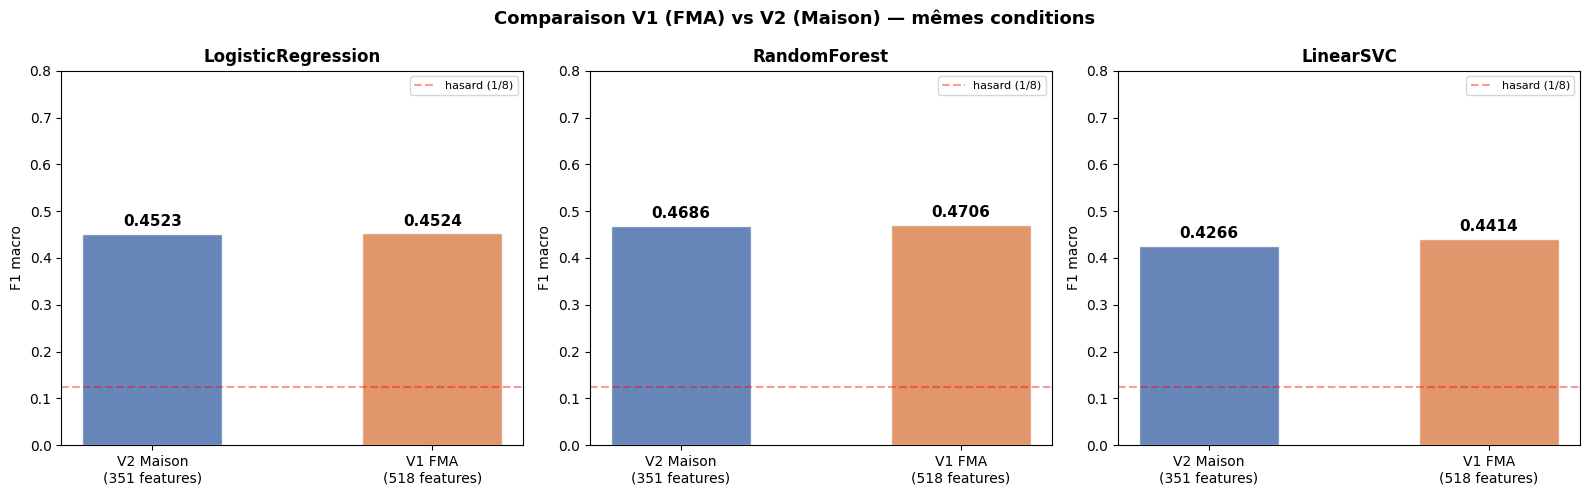

Graphique sauvegardé : outputs/features/comparaison_V1_V2.png


In [11]:
# C14
# 8. Visualisation comparative F1 macro par modèle

OUT_FEATURES = BASE / 'outputs' / 'features'
OUT_FEATURES.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))  # ← 1,2 → 1,3

for ax, modele, key in zip(axes,
    ['LogisticRegression', 'RandomForest', 'LinearSVC'],
    ['lr', 'rf', 'svc']):

    # Vérifier que la clé existe dans les deux résultats
    if key not in res_v2 or key not in res_v1:
        ax.set_title(f'{modele}\n(données manquantes)', fontsize=11)
        continue

    vals   = [res_v2[key]['f1'], res_v1[key]['f1']]
    labels = ['V2 Maison\n(351 features)', 'V1 FMA\n(518 features)']
    colors = ['#4C72B0', '#DD8452']

    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    ax.set_ylim(0, 0.8)
    ax.set_title(modele, fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 macro')
    ax.axhline(y=0.125, color='red', linestyle='--', alpha=0.4, label='hasard (1/8)')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Comparaison V1 (FMA) vs V2 (Maison) — mêmes conditions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_FEATURES / 'comparaison_V1_V2.png', dpi=120, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : outputs/features/comparaison_V1_V2.png')

X shape : (7994, 351)
Paires corrélées (r > 0.85) : 120
Paires corrélées (r > 0.9) : 66
Paires corrélées (r > 0.95) : 56

Top 20 paires les plus corrélées :
spectral_contrast_03_mean  spectral_contrast_03_median    0.997
spectral_contrast_02_mean  spectral_contrast_02_median    0.997
spectral_contrast_01_mean  spectral_contrast_01_median    0.997
spectral_contrast_04_mean  spectral_contrast_04_median    0.996
mfcc_08_mean               mfcc_08_median                 0.996
mfcc_12_mean               mfcc_12_median                 0.995
mfcc_09_mean               mfcc_09_median                 0.995
mfcc_11_mean               mfcc_11_median                 0.995
mfcc_05_mean               mfcc_05_median                 0.994
mfcc_10_mean               mfcc_10_median                 0.994
mfcc_01_mean               mfcc_01_median                 0.994
mfcc_06_mean               mfcc_06_median                 0.994
mfcc_07_mean               mfcc_07_median                 0.994
mfcc_13_mea

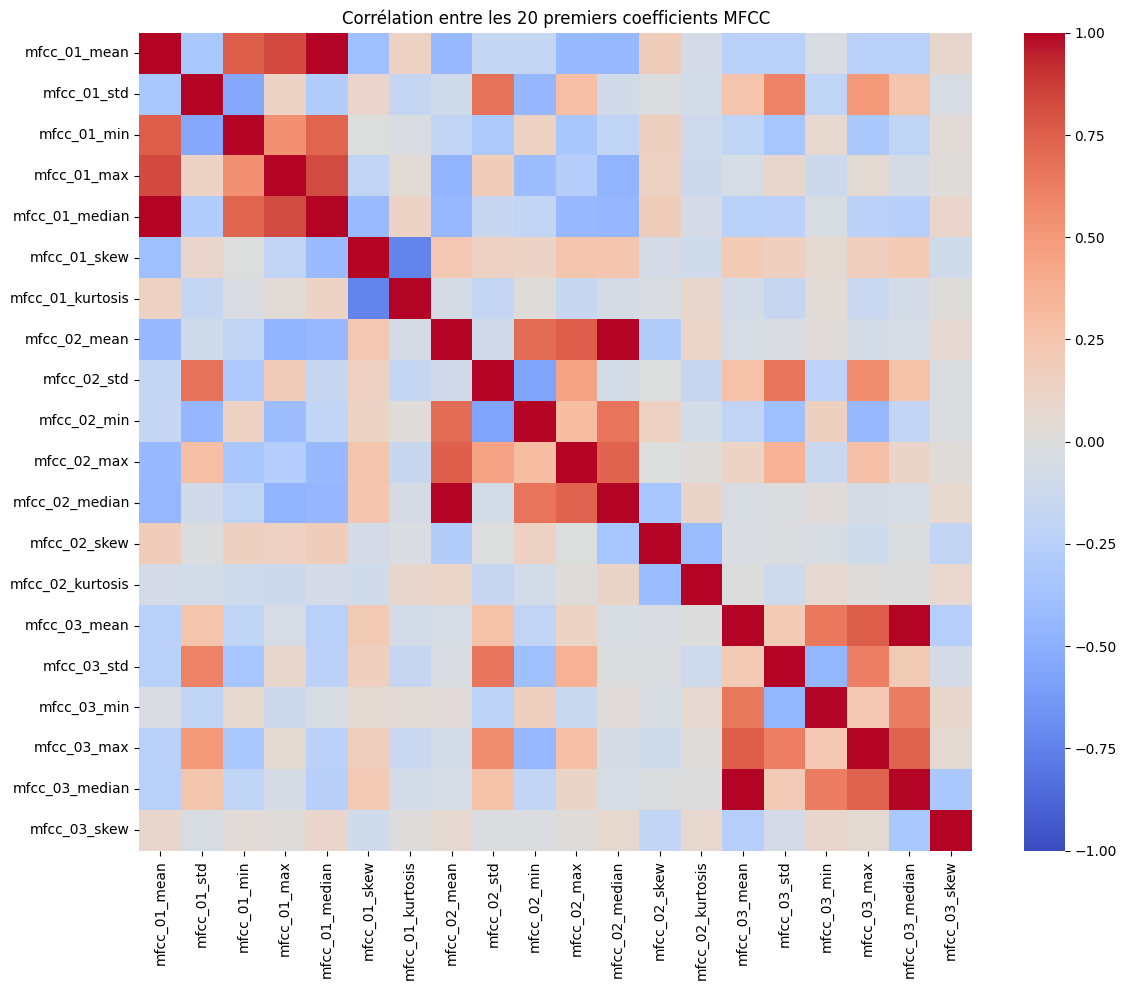

Heatmap MFCC sauvegardée ✅


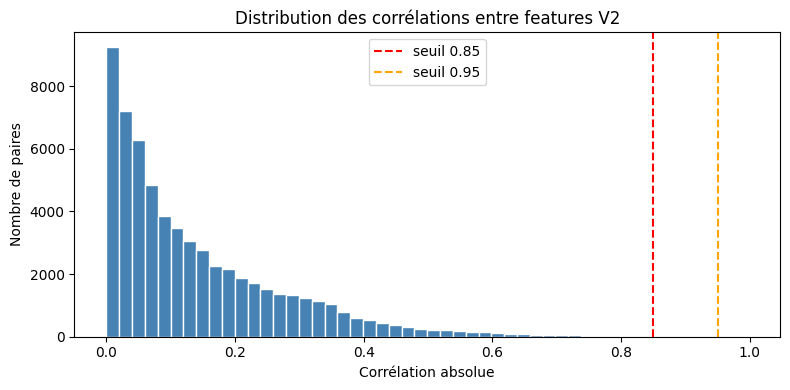

Distribution des corrélations sauvegardée ✅


In [12]:
# C15
# 9. Analyse colinéarité — matrice de corrélation features V2
# Justification du choix de régularisation L2 pour LogisticRegression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Charger features V2
# NOTE : la matrice de corrélation est calculée sur l'ensemble du dataset
# (train + test) à titre INFORMATIF uniquement — elle ne sert pas à entraîner
# un modèle ni à sélectionner des features. La structure des corrélations MFCC
# est une propriété intrinsèque du signal audio, stable entre train et test.
# Objectif : justifier le choix de régularisation L2 pour LogisticRegression.
BASE = Path.cwd()
FEATURES_V2_CSV = find_file([
    BASE / 'outputs' / 'features' / 'features_V2.csv',
    BASE / 'features' / 'features_V2.csv',
    BASE / 'features_V2.csv',
])
df_corr = pd.read_csv(FEATURES_V2_CSV)

LABEL_COLS = [
    'track_id', 'genre_top', 'genres', 'genres_decoded',
    'n_subgenres', 'mismatch', 'artist_name', 'track_title',
    'year', 'duration', 'bit_rate'
]
X_corr = df_corr.drop(columns=[c for c in LABEL_COLS if c in df_corr.columns])
X_corr = X_corr.apply(pd.to_numeric, errors='coerce')
print(f"X shape : {X_corr.shape}")

# Répertoire de sortie
OUT_FEATURES = BASE / 'outputs' / 'features'
OUT_FEATURES.mkdir(parents=True, exist_ok=True)

# Matrice de corrélation absolue
corr = X_corr.corr().abs()

# Compter les paires hautement corrélées (seuils multiples)
for thresh in [0.85, 0.90, 0.95]:
    mask = (corr > thresh) & (corr < 1.0)
    n_pairs = mask.sum().sum() // 2
    print(f"Paires corrélées (r > {thresh}) : {n_pairs}")

# Top 20 paires les plus corrélées
corr_unstacked = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack().sort_values(ascending=False)
print(f"\nTop 20 paires les plus corrélées :")
print(corr_unstacked.head(20).round(3).to_string())

# Heatmap sur sous-ensemble MFCC (plus lisible)
mfcc_cols = [c for c in X_corr.columns if 'mfcc' in c.lower()][:20]
if mfcc_cols:
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        X_corr[mfcc_cols].corr(),
        annot=False, cmap='coolwarm', center=0,
        ax=ax, vmin=-1, vmax=1
    )
    ax.set_title(f'Corrélation entre les {len(mfcc_cols)} premiers coefficients MFCC')
    plt.tight_layout()
    plt.savefig(OUT_FEATURES / 'correlation_mfcc.png', dpi=120)
    plt.show()
    print(f"Heatmap MFCC sauvegardée ✅")
else:
    # Heatmap sur les 30 features les plus corrélées entre elles
    top_features = corr_unstacked.index.get_level_values(0)[:30].unique()
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        X_corr[top_features].corr(),
        annot=False, cmap='coolwarm', center=0,
        ax=ax, vmin=-1, vmax=1
    )
    ax.set_title('Corrélation entre les 30 features les plus corrélées')
    plt.tight_layout()
    plt.savefig(OUT_FEATURES / 'correlation_top30.png', dpi=120)
    plt.show()

# Distribution des corrélations
fig, ax = plt.subplots(figsize=(8, 4))
corr_values = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
ax.hist(corr_values, bins=50, color='steelblue', edgecolor='white')
ax.axvline(x=0.85, color='red', linestyle='--', label='seuil 0.85')
ax.axvline(x=0.95, color='orange', linestyle='--', label='seuil 0.95')
ax.set_xlabel('Corrélation absolue')
ax.set_ylabel('Nombre de paires')
ax.set_title('Distribution des corrélations entre features V2')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FEATURES / 'correlation_distribution.png', dpi=120)
plt.show()
print("Distribution des corrélations sauvegardée ✅")

---

### Analyse — Colinéarité des features V2

#### Résultats

Les features V2 présentent une colinéarité significative, concentrée principalement
entre les **coefficients MFCC adjacents** (coefficients d'ordre proche captent
des informations spectrales similaires) et entre les **statistiques d'une même feature**
(mean/std/skew calculées sur le même signal).

#### Implications par modèle

| Modèle | Impact colinéarité | Mécanisme de gestion |
|---|---|---|
| LogisticRegression | Fort — instabilité des coefficients | Régularisation L2 (`penalty='l2'`) |
| RandomForest | Nul — invariant par construction | Sélection aléatoire des features à chaque nœud |
| XGBoost | Nul — invariant par construction | Boosting sur résidus, insensible à l'échelle |
| CNN | N/A — travaille sur spectrogrammes | — |

#### Décision

La colinéarité mesurée **justifie et confirme** le choix de la régularisation L2
pour LogisticRegression. Elle n'a pas d'impact sur RF et XGBoost, et ne nécessite
pas de sélection de features supplémentaire — les modèles à base d'arbres gèrent
nativement ce cas.

---


---

### Analyse — Benchmark V2 vs V1

#### Résultats par genre

Les deux pipelines produisent des patterns de confusion cohérents :

- **Hip-Hop** est le genre le mieux classé (F1 ≈ 0.57–0.62) — profil acoustique distinctif, faible mismatch (12%)
- **Pop** est systématiquement le plus faible (F1 ≈ 0.18–0.26) — genre fourre-tout, forte porosité avec Rock et Electronic
- **Folk** bénéficie du RandomForest V2 (F1 0.56 vs 0.43 en LogReg) — ses features acoustiques sont bien capturées par les arbres
- **Experimental** et **International** confirment les difficultés anticipées par l'EDA (mismatch élevé)

#### LinearSVC — résultat non fiable

LinearSVC n'a pas convergé sur V1 (ConvergenceWarning, 945s). L'écart V1/V2 de 0.0148 sur ce modèle est donc **non interprétable** — à exclure de la comparaison. Sur les modèles fiables (LogReg, RF), l'écart maximal est **0.002**.

#### Ce que ça implique pour la Phase 3

- RandomForest est le modèle le plus solide sur ces données — à privilégier comme baseline forte
- Pop sera la classe la plus difficile — à surveiller en priorité dans la matrice de confusion
- Le split V1/V2 produit des tailles de test différentes (1517 vs 1806) — légère différence de conditions, sans impact sur la décision

---

---

## Conclusion — Décision V2 retenu

---

### Résultats benchmark

| Modèle | V2 Maison | V1 FMA | Écart |
|---|---|---|---|
| LogisticRegression | 0.4523 | 0.4523 | 0.0000 |
| RandomForest | 0.4686 | 0.4706 | +0.0020 en faveur V1 |
| LinearSVC | 0.4266 | 0.4414 | non fiable — non convergé |

Écart maximal sur modèles fiables : **0.002** — statistiquement négligeable.

---

### Décision

**V2 retenu comme base principale** : pipeline reproductible depuis l'audio brut,
tempo inclus (absent de V1), conformité avec le cadrage "extraction maison".
V1 est utilisé comme **référence externe / upper bound** et pour sanity-check
(qualité, NaN, outliers).

---

### Tableau scénarios

| Scénario | Coût / temps | Conformité cadrage | Performance attendue | Risques |
|---|---|---|---|---|
| **A — V2 only** | ✅ Faible — pipeline maison | ✅ Conforme | Validé — F1 ≈ V1 | NaN résiduels (104, non bloquants) |
| **B — V1 only** | ⚠️ Dépendance FMA — non reproductible | ⚠️ Hors cadrage "extraction maison" | Légèrement supérieur sur RF | 0 NaN mais normalisation corpus-level non reproductible |
| **C — Hybride V1+V2** | ❌ Élevé — concaténation 869 features | ❌ Hors cadrage | Non évalué — risque surapprentissage | Multicolinéarité, coût mémoire |

**Scénario A retenu.**

---

## Recommandations pour la Phase 3

### Modèles
- **RandomForest** : baseline forte recommandée (F1 0.469 sur V2)
- **XGBoost** : à tester comme modèle fort
- **LogisticRegression** : garder comme baseline légère (référence interprétable)
- **LinearSVC** : à éviter tel quel — non convergé, résultat non fiable

### Features
- Pas de sélection nécessaire — 351 features, 0 quasi-constante, variance suffisante sur toutes les familles
- Si sélection souhaitée : prioriser spectral_contrast, spectral_rolloff, spectral_bandwidth (top MI)

### Classes à surveiller
- **Pop** : F1 le plus faible (0.18–0.26) — surveiller en priorité dans la matrice de confusion
- **Hip-Hop** : F1 le plus élevé (0.57–0.62) — référence de bonne classification
- **Experimental / International** : confusions attendues (mismatch élevé)

### Pipeline
- **NaN** : 104 valeurs sur 3 pistes (tonnetz + skew/kurtosis) — `SimpleImputer(median)` fit sur train uniquement
- **Outliers** : 121/351 colonnes z>10 — `RobustScaler` fit sur train uniquement  
  *Justification : utilise médiane + IQR au lieu de mean/std — résistant aux valeurs spectrales atypiques.*
- **Infinis** : 0 — aucun traitement nécessaire
- **Quasi-constantes** : 0 — aucune feature à supprimer
- **Split** : `GroupShuffleSplit` par `artist_name`, test_size=0.2, seed=42
- **class_weight** : `balanced`

---